In [1]:
import numpy as np
import scipy
import matplotlib.pyplot as plt
import sklearn
from lib.readwav import *

# Classificazione di note prodotte da un organo


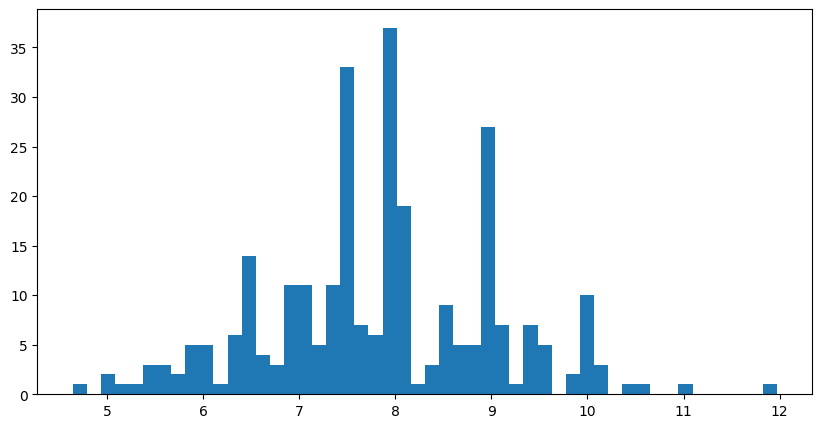

In [38]:
# Now we are curios to see the distribution of lengths of the signals, in the sense that we wonder if they're all
# 7 seconds long or something.

rates = []
notes = []
times = []
lengths = []
for i in range(1, 281):
    filename = "./wav_files/note_{}.wav".format(i)
    rate, note = readwav(filename)
    time = np.linspace(0, note.shape[0], note.shape[0], endpoint = False) / rate
    lengths.append(np.max(time))
    times.append(time)
    rates.append(rate)
    notes.append(note[:, 0])

rates = np.array(rates)
notes = np.array(notes, dtype=object)
times = np.array(times, dtype=object)

plt.figure(figsize = (10, 5))
plt.hist(lengths, bins=50)
plt.show()
# Lengths go from 4s to 12s excluded, let's say

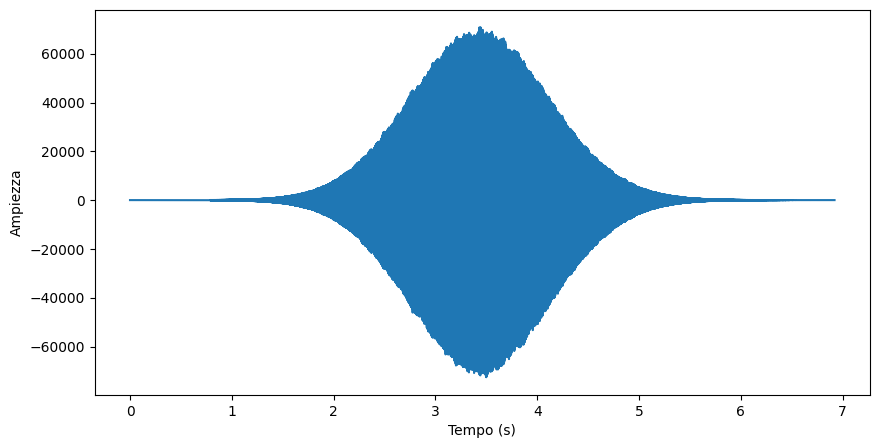

In [ ]:
# Implementiamo la finestra gaussiana da applicare al segnale, in modo da attenure l'attacco e il decadimento
def gaussian_window(signal, sigma):
    n = signal.shape[0]
    x = np.arange(n)
    center = 0.5 * n
    window = np.exp(-0.5 * ((x - center) / sigma) ** 2)
    return signal * window

masked_notes = []
for note in notes:
    masked_note = gaussian_window(note, sigma=note.shape[0] / 10)
    masked_notes.append(masked_note)    

masked_notes = np.array(masked_notes, dtype=object)

# Visualizziamo il primo segnale con la finestra gaussiana
plt.figure(figsize=(10, 5))
plt.plot(times[0], masked_notes[0])
plt.xlabel("Tempo (s)")
plt.ylabel("Ampiezza")
plt.show()

In [48]:
# Facciamo la fft dei segnali mascherati
ffts = []
for note in masked_notes:
    fft = scipy.fft.rfft(note)
    ffts.append(fft)
ffts = np.array(ffts, dtype=object)

power_spectra = np.abs(ffts)**2

frequency_axes = []

for masked_note, rate in zip(masked_notes, rates):
    frequencies = scipy.fft.rfftfreq(masked_note.shape[0], d=1/rate)
    frequency_axes.append(frequencies)

frequency_axes = np.array(frequency_axes, dtype=object)

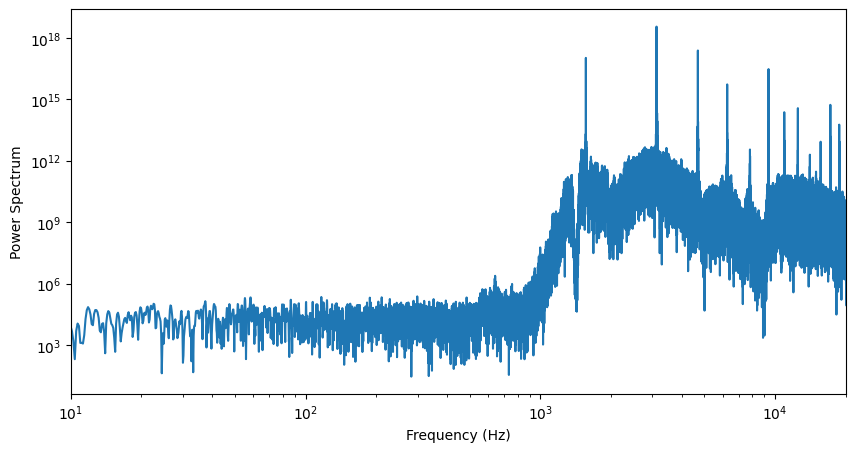

In [50]:
# Plot dello spettro di potenza del primo segnale mascherato
plt.figure(figsize=(10, 5))
plt.loglog(frequency_axes[0], power_spectra[0])
plt.xlabel("Frequency (Hz)")
plt.ylabel("Power Spectrum")
plt.xlim(10, 20000)

plt.show()
